In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
def f(x):
    return 4*x**2-4*x+5


In [3]:
f(4)

53

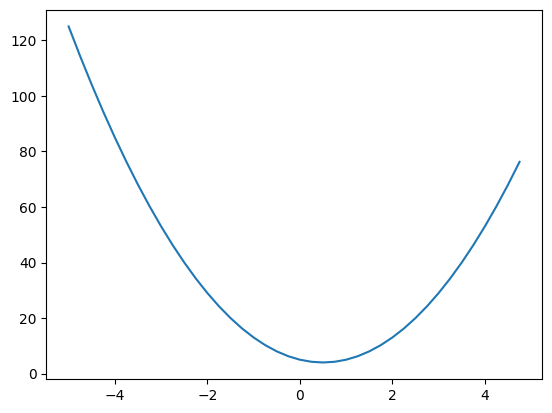

In [4]:
xs=np.arange(-5,5,0.25)
ys=f(xs)
plt.plot(xs, ys)

In [5]:
h=0.001
x=4
(f(x+h) - f(x)) / h

28.00400000000991

In [6]:
a=2.0
b=-3.0
c=10.0
h=0.0001
d=a*b+c
print(d)


4.0


In [7]:
a=2.0
b=-3.0
c=10.0
h=0.0001
d1=a*b+c
a+=h
d2=a*b+c
print(d1, d2, (d2-d1)/h)

4.0 3.999699999999999 -3.000000000010772


In [8]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out=Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += out.grad * 1.0
            other.grad += out.grad * 1.0
        out._backward = _backward
        return out
    def __rmul__(self, other):  # other * self
        return self * other
    def __truediv__(self, other):  # self / other
        return self * other**-1
    def __neg__(self):  # -self
        return self * -1
    def __sub__(self, other):  # self - other
        return self + (-other)
    def __rsub__(self, other):  # other - self
        return other + (-self)
    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out=Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad+=out.grad*other.data
            other.grad+=out.grad*self.data
        out._backward=_backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out=Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad+=out.grad*other*self.data**(other-1)
        out._backward=_backward
        return out
    def tanh(self):
        x=self.data
        t=(math.exp(x*2)-1)/(math.exp(x*2)+1)
        out = Value(t, (self,), 'tanh')

        def _backward():
            self.grad+=out.grad*(1-t**2)
        out._backward=_backward
        return out
    def exp(self):
        x=self.data
        out=Value(math.exp(x),(self,),'exp')
        def _backward():
            self.grad=out.data*out.grad
        out._backward=_backward
        return out
    def backward(self):
        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad=1.0
        for node in reversed(topo):
            node._backward()


a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f= Value(-2.0, label='f')
L=d * f; L.label = 'L'
L


Value(data=-8.0)

In [9]:
a=Value(2.0, label='a')
b=Value(4.0, label='b')
a-b

Value(data=-2.0)

In [10]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [11]:
d._op

'+'

In [12]:
from graphviz import Digraph

def trace(root):
    #built a set of all the nodes and edges in the graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) #LR= left to right
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        #for any value in the graph, create a rectangular ('record') node for  it
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label,n.data,n.grad), shape='record')
        if n._op:
            #if this value is a result of some operation, create an op node for it
            dot.node(name=uid+n._op, label=n._op)
            #and connect this node to it
            dot.edge(uid+n._op, uid)

    for n1, n2 in edges:
        #for each edge, connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [13]:
def lol():
    h=0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f= Value(-2.0, label='f')
    L=d * f; L.label = 'L'
    L1=L.data
    a = Value(2.0+h, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f= Value(-2.0, label='f')
    L=d * f; L.label = 'L'
    L2=L.data
    print((L2-L1)/h)

lol()


6.000000000021544


In [14]:
#input x1,x2
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
w1=Value(-3.0, label='w1')
w2=Value(1.0, label='w2')
b=Value(6.8813735870195432, label='b')
x1w1=x1*w1; x1w1.label='x1*w1'
x2w2=x2*w2; x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n=x1w1x2w2+b; n.label='n'
o=n.tanh(); o.label='o'
o.backward()

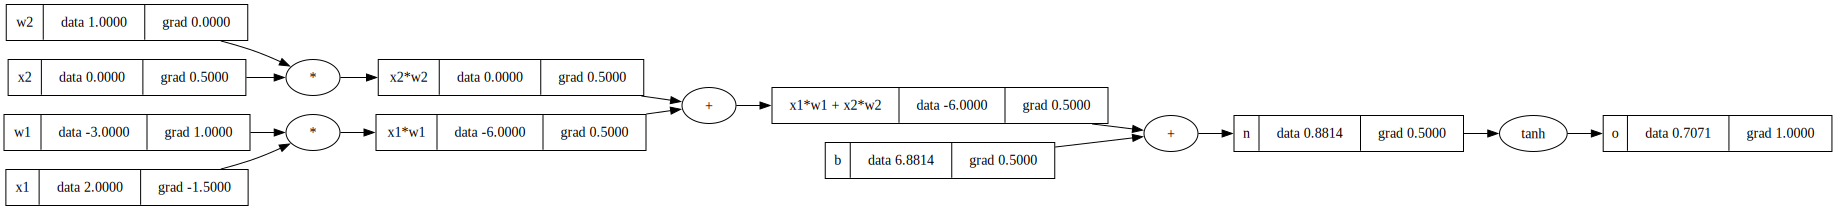

In [15]:
draw_dot(o)

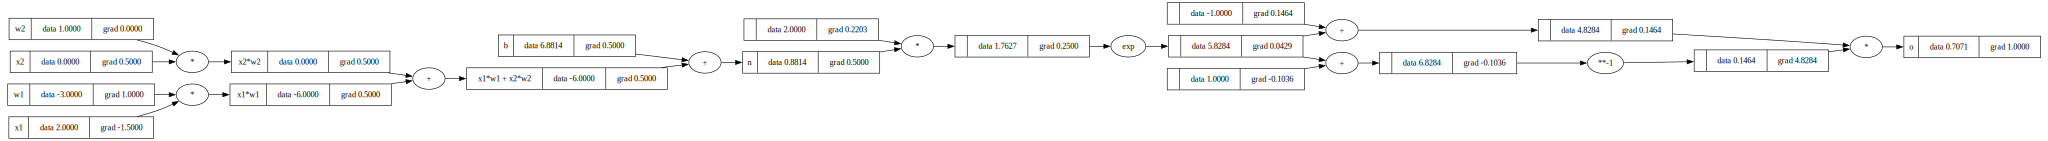

In [16]:
#input x1,x2
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
w1=Value(-3.0, label='w1')
w2=Value(1.0, label='w2')
b=Value(6.8813735870195432, label='b')
x1w1=x1*w1; x1w1.label='x1*w1'
x2w2=x2*w2; x2w2.label='x2*w2'
x1w1x2w2=x1w1+x2w2; x1w1x2w2.label='x1*w1 + x2*w2'
n=x1w1x2w2+b; n.label='n'
#---
e=(2*n).exp()
o=(e-1)/(e+1)
o.label='o'
o.backward()
draw_dot(o)

In [17]:
import torch
import random

In [18]:


x1=torch.Tensor([2.0]).double()              ;x1.requires_grad_(True)
x2=torch.Tensor([0.0]).double()              ;x2.requires_grad_(True)
w1=torch.Tensor([-3.0]).double()             ;w1.requires_grad_(True)
w2=torch.Tensor([1.0]).double()              ;w2.requires_grad_(True)
b=torch.Tensor([6.8813735870195432]).double() ;b.requires_grad=True
n=x1*w1+x2*w2+b
o=torch.tanh(n)

print(o.data.item())
o.backward()

print('----')
print('x2',x2.grad.item())
print('w2',w2.grad.item())
print('x1',x1.grad.item())
print('w1',w1.grad.item())

0.7071066904050358
----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [19]:
o.item()

0.7071066904050358

In [20]:
class Neuron:
    def __init__(self,nin):
        self.w=[(Value(random.uniform(-1,1))) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))
    
    def __call__(self,x):
        # w*x+b
        act=sum((wi*xi for wi,xi in  zip(self.w,x)),self.b)
        out=act.tanh()
        return out
    
    def parameters(self):
        return self.w+[self.b]
class Layer:
    def __init__(self,nin,nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]
    def __call__(self,x):
        outs=[n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs
    
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        
class MLP:
    def __init__(self,nin,nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]
    def __call__(self, x):
        for layer in self.layers:
            x=layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
        


In [21]:
x=[2.0, 3.0,-1.0]
n=MLP(3,[4,4,1])
n(x)

Value(data=0.5797648006448182)

In [27]:
n.parameters()

[Value(data=0.058801849624191105),
 Value(data=-0.5187509599819613),
 Value(data=0.2565055511296628),
 Value(data=0.5499394752637754),
 Value(data=-0.1522807178707164),
 Value(data=0.810378930839506),
 Value(data=0.8142361715404092),
 Value(data=-0.9980439594521182),
 Value(data=0.6055887967416309),
 Value(data=-0.3577645920796684),
 Value(data=-0.5567338004035984),
 Value(data=-0.23822844094365703),
 Value(data=0.8178135882117927),
 Value(data=0.15277166779681584),
 Value(data=0.7849377407013176),
 Value(data=-0.6196974317500545),
 Value(data=0.42828997262300805),
 Value(data=-0.9444467364244566),
 Value(data=0.6819814915815348),
 Value(data=0.7623123252390158),
 Value(data=0.6785079885792431),
 Value(data=-0.5650859709895069),
 Value(data=0.37945473217723835),
 Value(data=0.04301787889427389),
 Value(data=0.11258431699525961),
 Value(data=-0.8710986780241492),
 Value(data=-0.03984049260090594),
 Value(data=-0.9720698398786505),
 Value(data=-0.5424074063901168),
 Value(data=0.55389666

In [23]:
xs=[
    [2.0,3.0,-1.0],
    [3.0,-1.0,0.5],
    [0.5,1.0,1.0],
    [1.0,1.0,-1.0]
]
ys=[1.0,-1.0,-1.0,1.0]
ypred=[n(x) for x in xs]
ypred

[Value(data=0.5797648006448182),
 Value(data=0.8451474318902269),
 Value(data=0.7735956074296704),
 Value(data=0.7819771984208379)]

In [32]:
for k in range(10):
    ypred=[n(x) for x in xs]
    loss=sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))
    print(k, loss.data)
    
    for p in n.parameters():
        p.grad=0.0
    
    loss.backward()
    
    for p in n.parameters():
        p.data+=-0.01*p.grad
    print(k, loss.data)

0 6.642034322099515
0 6.642034322099515
1 6.490742750597319
1 6.490742750597319
2 6.318375790532327
2 6.318375790532327
3 6.1237676758498685
3 6.1237676758498685
4 5.907527012371503
4 5.907527012371503
5 5.673089127936263
5 5.673089127936263
6 5.427614497182267
6 5.427614497182267
7 5.182035414114328
7 5.182035414114328
8 4.949500310211716
8 4.949500310211716
9 4.742198764004446
9 4.742198764004446


In [31]:
loss=sum((yout-ygt)**2 for ygt,yout in zip(ys,ypred))
loss


Value(data=6.774341988890438)

In [25]:
loss.backward()

In [26]:
n.layers[0].neurons[0].w[0].grad

-0.024173244920799225

In [28]:
n.layers[0].neurons[0].w[0].data

0.058801849624191105

In [29]:
for p in n.parameters():
    p.data+=-0.01*p.grad

In [30]:
n.layers[0].neurons[0].w[0].data

0.0590435820733991